In [ ]:
# Imports y utilidades
import sys
# Añadir la raíz del repo al sys.path para poder importar paquetes locales
from pathlib import Path
repo_root = str(Path('..').resolve())
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
import numpy as np

try:
    import open3d as o3d
except Exception as e:
    print('Advertencia: open3d no está instalado o cargó con error:', e)


def load_pcd(path):
    p = o3d.io.read_point_cloud(str(path))
    pts = np.asarray(p.points)
    return p, pts


def summary_points(pts):
    print('N puntos:', pts.shape[0])
    if pts.shape[0] > 0:
        print('X range:', pts[:,0].min(), pts[:,0].max())
        print('Y range:', pts[:,1].min(), pts[:,1].max())
        print('Z range:', pts[:,2].min(), pts[:,2].max())
        print('Mean Z:', pts[:,2].mean(), 'Std Z:', pts[:,2].std())


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
# Cargar un PCD de ejemplo
base = Path('../docs/Pruebas_posicion_2')
pcds = sorted(base.glob('*.pcd'))
print('Encontrados', len(pcds), 'pcd en', base)
if len(pcds) > 0:
    p = pcds[0]
    print('Usando ejemplo:', p)
    pcd, pts = load_pcd(p)
    summary_points(pts)
    # Visualizar (si el entorno lo permite)
    try:
        o3d.visualization.draw_geometries([pcd])
    except Exception as e:
        print('No se pudo lanzar visualización (posible entorno headless):', e)


Encontrados 158 pcd en ../docs/Pruebas_posicion_2
Usando ejemplo: ../docs/Pruebas_posicion_2/1758208492.275396347.pcd
N puntos: 23732
X range: -15.59691047668457 9.129003524780273
Y range: -5.014274597167969 2.2174172401428223
Z range: -0.9989053606987 3.5948097705841064
Mean Z: 0.16696093317774904 Std Z: 0.5340349553332113


## Exploración extendida y recomendaciones

Esta sección añade herramientas rápidas para:
- calcular estadísticas por archivo `.pcd` (n puntos, rangos XYZ, media/desviación de altura),
- visualizar histogramas de alturas (Z) y densidad aproximada,
- muestrear varios archivos y proponer parámetros de preprocesado (voxel size, outlier removal),
- ejecutar un preprocesado de ejemplo usando `preprocess/pcd_preprocess.py` vía su función `preprocess_file`.

Requisitos: tener instaladas las librerías del `requirements.txt`, especialmente `open3d` y `matplotlib` (instala con `pip install open3d matplotlib`).

Archivo: ../docs/Pruebas_posicion_2/1758208492.275396347.pcd
N puntos: 23732
X range: -15.59691047668457 9.129003524780273
Y range: -5.014274597167969 2.2174172401428223
Z range: -0.9989053606987 3.5948097705841064
Mean Z: 0.16696093317774904 Std Z: 0.5340349553332113


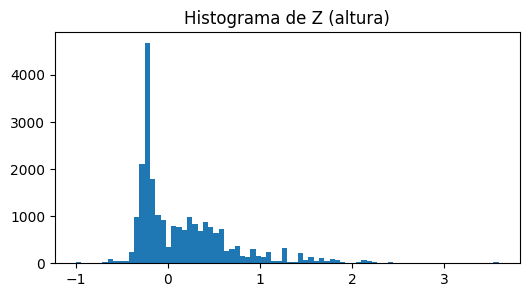

Recomendado voxel ~ 0.0262 m  | outlier nb=20 std=1.0
Archivo: ../docs/Pruebas_posicion_2/1758208492.375915289.pcd
N puntos: 23766
X range: -15.59930419921875 9.126569747924805
Y range: -5.014274597167969 2.2166590690612793
Z range: -0.9992960095405579 3.599867343902588
Mean Z: 0.16688787149682202 Std Z: 0.5329760380604838


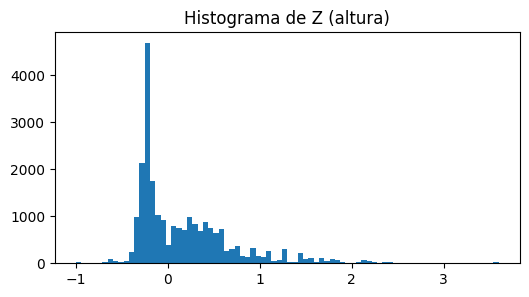

Recomendado voxel ~ 0.0262 m  | outlier nb=20 std=1.0
Archivo: ../docs/Pruebas_posicion_2/1758208492.475525379.pcd
N puntos: 23789
X range: -15.601781845092773 9.124134063720703
Y range: -5.00753116607666 2.216249465942383
Z range: -0.9981240630149841 3.5914382934570312
Mean Z: 0.1660862570720368 Std Z: 0.5325129390145205


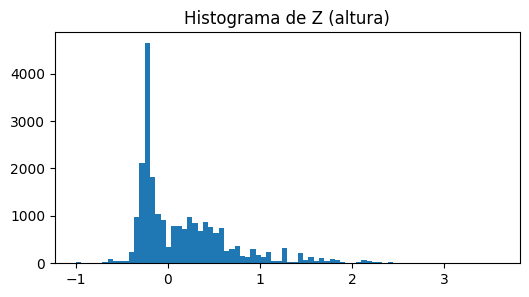

Recomendado voxel ~ 0.0262 m  | outlier nb=20 std=1.0


In [3]:
# Estadísticas y visualizaciones adicionales
import matplotlib.pyplot as plt


def stats_for_pcd(path):
    pcd, pts = load_pcd(path)
    print('Archivo:', path)
    summary_points(pts)
    plt.figure(figsize=(6,3))
    plt.hist(pts[:,2], bins=80)
    plt.title('Histograma de Z (altura)')
    plt.show()


def recommend_params(pts):
    # heurística simple: voxel size ~ 1/100 de la diagonal del bbox
    mins = pts.min(axis=0)
    maxs = pts.max(axis=0)
    diag = np.linalg.norm(maxs-mins)
    voxel = max(0.01, diag / 1000.0)
    # nb neighbors por defecto
    nb = 20
    std = 1.0
    print(f'Recomendado voxel ~ {voxel:.4f} m  | outlier nb={nb} std={std}')
    return voxel, (nb, std)

# Muestrear N archivos y mostrar recomendaciones
base = Path('../docs/Pruebas_posicion_2')
pcds = sorted(base.glob('*.pcd'))
for p in pcds[0:3]:
    stats_for_pcd(p)
    pts = np.asarray(o3d.io.read_point_cloud(str(p)).points)
    recommend_params(pts)


In [14]:
# Ejecutar preprocesado usando la función si se quiere (ejemplo)
try:
    from preprocess.pcd_preprocess import preprocess_file
except Exception as e:
    # Intentar añadir la raíz del repo y reintentar (útil si el kernel no re-ejecutó la primera celda)
    import sys
    from pathlib import Path as _Path
    repo_root = str(_Path('..').resolve())
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)
    try:
        from preprocess.pcd_preprocess import preprocess_file
    except Exception as e2:
        print('ERROR al importar preprocess después de añadir repo_root:', e2)
        raise

example = Path('../docs/Pruebas_posicion_2') / sorted(base.glob('*.pcd'))[0].name
out = Path('../data/preprocessed')
res = preprocess_file(example, out, voxel_size=0.02, remove_outliers=(20,1.0), estimate_normals=False)
print('Resultado preprocess:', res)


Procesando: ../docs/Pruebas_posicion_2/1758208492.275396347.pcd
Puntos originales: 23732
Aplicando StatisticalOutlierRemoval nb_neighbors=20 std_ratio=1.0
Puntos tras outlier removal: 21349
Aplicando voxel downsample size=0.02
Puntos tras voxel: 12874
Guardado: ../data/preprocessed/1758208492.275396347.npy  (151.0KB)
Guardado: ../data/preprocessed/1758208492.275396347.ply  (301.9KB)
Resultado preprocess: {'n_points': 12874, 'np_path': '../data/preprocessed/1758208492.275396347.npy', 'ply_path': '../data/preprocessed/1758208492.275396347.ply'}
